In [1]:
using LinearAlgebra
using Plots
using SparseArrays
using Arpack

In [2]:
g = 1.5;
κ = 0.2;
L = 40;
dx = .1;
N = Integer(L/dx + 1);

This generates the steady-state soliton found from the equation:
$\partial_x^2 \phi_\text{ss} - \kappa \sqrt{\pi} \sin(2\sqrt{\pi} \phi_\text{ss}) + g^2 \phi_\text{ss} + g^2 \sqrt{\pi} \Theta(x)$
using a Newton's method style solver.

In [3]:
function solve_soliton(g, κ, L, N; Θ::Function = x -> (x ≥ 0 ? 1.0 : 0.0), tol::Real = 1e-9, maxiter::Integer = 30, verbose::Bool = true)
    xrange = range(-L/2, L/2; length=N)
    dx = step(xrange)
    k = κ*sqrt(π) #coeff of sine term
    g0 = g^2 #coeff of mass term
    φ_left, φ_right = 0.0, -sqrt(π) 

    # initial guess is the SG soliton
    φ = @. -(2/sqrt(π))*atan(exp(sqrt(2*π*κ)*xrange)) 
    src = Θ.(xrange)   #applies Heaviside function to defined grid
    F  = zeros(N)   #function we want equal to zero (difference between guess and solution)
    
    function residual!(F, φ)
        F[1] = φ[1] - φ_left
        F[N] = φ[N] - φ_right
        @inbounds for i in 2:N-1 #skips check that array element is a valid one to speed up loop
            laplacian = (φ[i+1] - 2φ[i] + φ[i-1])/dx^2
            F[i] = laplacian - k*sin(2*sqrt(π)*φ[i]) - g0*φ[i] - sqrt(π)*g0*src[i] 
        end
        return F
    end

    dl = zeros(N - 1)   # sub diagonal of Jacobian
    d  = zeros(N)   # diagonal
    du = zeros(N - 1)   # super diagonal
    
    function jacobian!(dl, d, du, φ)
        d[1] = 1.0
        d[N] = 1.0
        @inbounds for i in 2:N-1
            d[i] = -2.0/dx^2 - 2*sqrt(π)*k*cos(2*sqrt(π)*φ[i]) - g0 #derivative of residual w/r/t φ[i] of discretized equation
            dl[i-1] = 1.0/dx^2
            du[i-1] = 1.0/dx^2
        end
        return Tridiagonal(dl, d, du)
    end
    
    for iter in 1:maxiter
        residual!(F, φ)
        resnorm = norm(F)
        verbose && println("iter $iter:  ‖F‖ = $resnorm") #&& can be used for short circuit evaluation - in a && b, the expression b is only evaluated if a evaluates to true
        if resnorm < tol
            verbose && println("Converged in $iter iterations.")
            return xrange, φ
        end
        J  = jacobian!(dl, d, du, φ) #tangent line from F[ϕ] to zero has this slope
        Δφ = J \ (-F) #left division, computes -F = Δϕ J , gives Δϕ which adjusts ϕ to the value where the tangent line hits zero
        φ .+= Δφ
    end
    
    @warn "Newton iteration did not reach tol = $tol within $maxiter steps " *
          "(‖F‖ = $(norm(residual!(F, φ))))."
    return xrange, φ
end

solve_soliton (generic function with 1 method)

iter 1:  ‖F‖ = 6.681361570368385
iter 2:  ‖F‖ = 0.5049445025464252
iter 3:  ‖F‖ = 0.003007136455157974
iter 4:  ‖F‖ = 1.9240969799276587e-7
iter 5:  ‖F‖ = 2.658653754314144e-10
Converged in 5 iterations.


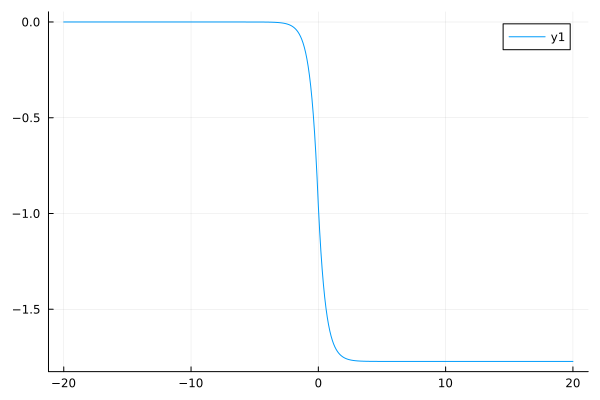

In [4]:
xrange, ϕ_ss = solve_soliton(g, κ, L, N)
plt = plot(xrange, ϕ_ss)

#uncomment below code if you want to see the comparison between my ss solver and wentao's for the given g and kappa

#=
using CSV, DataFrames
df = CSV.read("/Users/zoe/Documents/AnalogSimProject/Atom Steady States/SS_L200_dx0p1_g1p5_k0p2.csv", DataFrame, header=false)
phi_ss_original = df[:, 1]
N = length(phi_ss_original)
xnew = range(-100, step=0.01, length=N) 
display(plot!(plt, xnew,phi_ss_original, ls=:dash))
L = 40; #resetting to correct val
dx = .1; #resetting to correct val
N = Integer(L/dx + 1); #resetting to correct val
=#

This generates the finite difference version of the matrix:
$-\partial_x^2 - k_n^2 - 2\pi \kappa (1- \cos(2\sqrt{\pi} \phi_\text{ss}(x))) $

In [5]:
function FDmatrix(N, k, dx)
    #building laplacian
    laplacian = ComplexF64.(spdiagm(0 => fill(-2.0, N), -1 => fill(1.0, N-1), 1 => fill(1.0, N-1)))
    laplacian[1,1] = -(1 - im*k*dx)
    laplacian[end,end] = -(1 - im*k*dx)
    laplacianMat = (1/dx^2).*laplacian
    #building cos term
    costerm = zeros(N)
    @inbounds for i in 1:N
            costerm[i] = 2*π*κ*(1 - cos(2*sqrt(π)*ϕ_ss[i]))
        end
    costermMat = Diagonal(costerm)
    #building k term
    ktermMat = Diagonal(fill(k^2,N))
    #building full finite difference matrix
    fdMat = - laplacianMat - costermMat - ktermMat
    return fdMat
end

FDmatrix (generic function with 1 method)

This takes in $k$ and generates the matrix and outputs the lowest singular value and its corresponding eigenvector

In [6]:
function singval(kre, kim, N, dx)
    k = kre + im*kim
    testmat = FDmatrix(N, k, dx)
    u, s, v = svd(Matrix(testmat))
    σmin = s[end]
    evec = v[:,end]
    return σmin, evec
end

singval (generic function with 1 method)

WARNING - THIS TAKE ~2 HOURS TO RUN WITH CURRENT PARAMETERS

This takes a range of $k$ values and calculates the lowest singular value for each matrix as a function of $k$ and puts them in an array

In [7]:
kimvals = range(-2, 2; length=401)
krevals = range(-2, 2; length=401)
singvalslist = zeros(length(krevals),length(kimvals))
@inbounds for i in 1:length(krevals)
    @inbounds for j in 1:length(kimvals)
        σ, vec = singval(krevals[i], kimvals[j], N, dx)
        singvalslist[i,j] = σ
    end
end

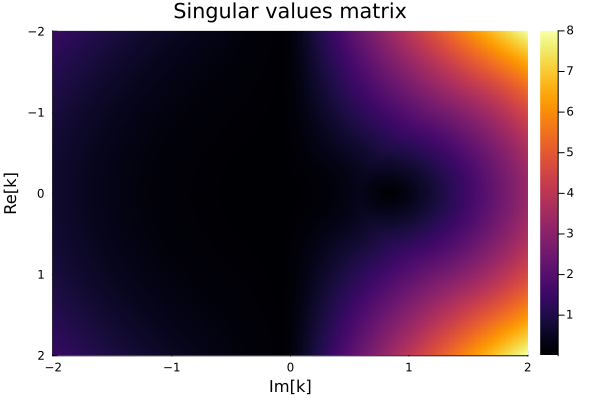

In [9]:
heatmap(kimvals, krevals, singvalslist, yflip = true, title = "Singular values matrix", xlabel = "Im[k]", ylabel = "Re[k]")

Meh first attempt at a minima solver.  Checks that a point is smaller than some tolerance, if it is checks to see if it is smaller than all other points within a predefinined radius.  I'm kind of cheating here because I know how far apart the answers usually are from my previous code, if you were to try new values you would need to mess around with vals for tolerance and radius.

In [19]:
function minima_finder(matrix, radius; tol=1e-3)
    rownum, colnum = size(matrix)
    minimalist = []
    for i in (radius+1):(rownum-radius)
        for j in (radius+1):(colnum-radius)
            if matrix[i,j] <= tol
                window = @view matrix[i-radius:i+radius, j-radius:j+radius]
                if matrix[i,j] == minimum(window)
                    push!(minimalist, [i,j])
                end
            end
        end
    end
    return minimalist
end

minima_finder (generic function with 1 method)

Takes the positions of all the minima, finds the corresponding $k_n$ and $\phi_n$ and puts them in lists

In [21]:
minpos = minima_finder(singvalslist, 3)
krelist = []
kimlist = []
eveclist = []
for i in 1:length(minpos)
    row, col = minpos[i]
    push!(krelist, krevals[row])
    push!(kimlist, kimvals[col])
    σ, ϕ = singval(krevals[row],kimvals[col],N,dx)
    push!(eveclist, ϕ)
end

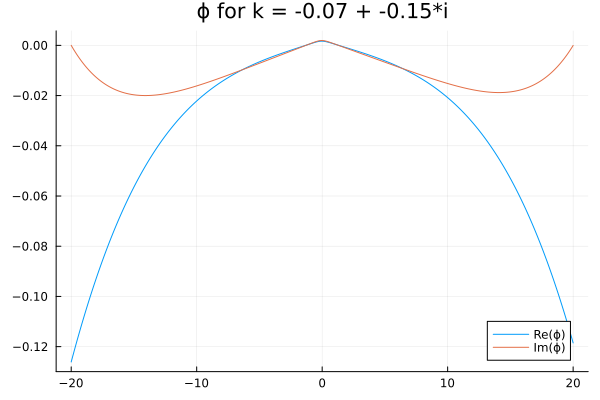

In [42]:
kplot = 9
plot(xrange, real.(eveclist[kplot]), title = "ϕ for k = $(krelist[kplot]) + $(kimlist[kplot])*i", label= "Re(ϕ)")
plot!(xrange, imag.(eveclist[kplot]), label = "Im(ϕ)")

Clearly i need to play around with the minima finder a bit more, I think this only generates half the number of eigenvectors the previous code did

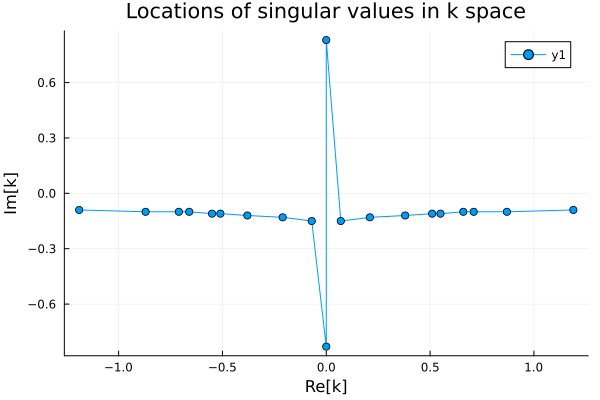

In [25]:
plot(krelist, kimlist, xlabel = "Re[k]", ylabel = "Im[k]", title = "Locations of singular values in k space", marker=:circle)

In [28]:
kimlist[10]

-0.83